# Veri Drift Tespiti (Kredi Skor Verisi)

Bu notebook'da kredi skor sınıflandırma verisi üzerinde veri drift tespiti yöntemleri uygulanacaktır.

**Veri Seti:** [Credit Score Classification - parisrohan/credit-score-classification](https://www.kaggle.com/datasets/parisrohan/credit-score-classification)

**Yöntemler:** KS Testi, Chi-Kare Testi, PSI, Jensen-Shannon Divergence, Evidently AI

In [1]:
# Gerekli paketlerin kurulumu
!pip install -q numpy pandas matplotlib scipy scikit-learn evidently kaggle

# İçe aktarmalar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.spatial.distance import jensenshannon
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Evidently - farklı versiyonlar için uyumlu import
evidently_available = False
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset
    evidently_available = True
except ImportError:
    try:
        from evidently import Report
        from evidently.presets import DataDriftPreset
        evidently_available = True
    except ImportError:
        print('evidently bulunamadı, manuel drift analizi kullanılacak')

print('Tüm paketler başarıyla yüklendi!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.8/581.8 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.8 MB/s eta 0:00:00
Tüm paketler başarıyla yüklendi!


## 1. Veri Setini İndirme

In [2]:
# Kaggle API ile veri setini indirme
import os
import subprocess

def create_synthetic_credit_data():
    """Senteetik kredi skor verisi olusturur (numpy/pandas ile)"""
    np.random.seed(42)
    n_samples = 10000

    data = {
        'annual_income': np.random.lognormal(mean=10.5, sigma=0.8, size=n_samples).astype(int),
        'monthly_inhand_salary': np.random.lognormal(mean=8.5, sigma=0.7, size=n_samples).astype(int),
        'num_bank_accounts': np.random.poisson(lam=3, size=n_samples) + 1,
        'num_credit_card': np.random.poisson(lam=2, size=n_samples) + 1,
        'interest_rate': np.random.uniform(1, 30, size=n_samples).round(1),
        'num_of_loan': np.random.poisson(lam=2, size=n_samples),
        'delay_from_due_date': np.random.randint(-10, 60, size=n_samples),
        'num_of_delayed_payment': np.random.poisson(lam=3, size=n_samples),
        'credit_history_age': np.random.uniform(0, 30, size=n_samples).round(1),
        'total_emi_per_month': np.random.lognormal(mean=6, sigma=1.2, size=n_samples).round(2),
        'amount_invested_monthly': np.random.lognormal(mean=5, sigma=1.5, size=n_samples).round(2),
        'monthly_balance': np.random.lognormal(mean=7, sigma=1.0, size=n_samples).round(2),
        'credit_mix': np.random.choice(['Good', 'Standard', 'Bad'], size=n_samples, p=[0.4, 0.35, 0.25]),
        'payment_of_min_amount': np.random.choice(['Yes', 'No', 'NM'], size=n_samples, p=[0.5, 0.3, 0.2]),
        'payment_behaviour': np.random.choice(
            ['High_spent_Small_value_payments', 'Low_spent_Large_value_payments',
             'High_spent_Medium_value_payments', 'Low_spent_Small_value_payments',
             'Medium_spent_Medium_value_payments', 'High_spent_Large_value_payments'],
            size=n_samples
        ),
        'credit_score': np.random.choice(['Good', 'Standard', 'Poor'], size=n_samples, p=[0.3, 0.5, 0.2])
    }

    return pd.DataFrame(data)

# Kaggle config dizinini olusturun (eger yoksa)
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# Kaggle ile indirmeyi dene, basarisiz olursa sentetik veri olustur
try:
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d',
         'parisrohan/credit-score-classification',
         '-p', './data', '--unzip'],
        capture_output=True, text=True, timeout=60
    )
    if result.returncode != 0:
        raise Exception(f'Kaggle CLI hatasi: {result.stderr}')

    data_files = os.listdir('./data')
    csv_files = [f for f in data_files if f.endswith('.csv')]
    if len(csv_files) == 0:
        raise Exception('CSV dosyasi bulunamadi')

    print(f"Kaggle'dan basariyla indirildi: {data_files}")
except Exception as e:
    print(f'Kaggle indirme hatasi: {e}')
    print('Senteetik kredi skor verisi olusturuluyor...')
    df = create_synthetic_credit_data()
    print(f'Senteetik veri olusturuldu: {df.shape}')
    data_files = ['synthetic_credit_data.csv']
    df.to_csv('./data/synthetic_credit_data.csv', index=False)

Kaggle'dan basariyla indirildi: ['train.csv', 'test.csv']


In [3]:
# Veri setini yukle (eger sentetik veri olusturulmadiysa)
if 'df' not in dir() or df is None:
    csv_files = [f for f in data_files if f.endswith('.csv')]
    print('CSV dosyalari:', csv_files)

    train_path = os.path.join('./data', csv_files[0])
    df = pd.read_csv(train_path)

print(f'Veri seti boyutu: {df.shape}')
print(f'Sutunlar: {list(df.columns)}')
df.head()

CSV dosyalari: ['train.csv', 'test.csv']
Veri seti boyutu: (100000, 28)
Sutunlar: ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 2. Veri Analizi

In [4]:
# Temel bilgiler
print('=== Veri Seti Bilgileri ===')
print(f'Satır sayısı: {df.shape[0]}')
print(f'Sütun sayısı: {df.shape[1]}')
print()
print('=== Veri Tipleri ===')
print(df.dtypes)
print()
print('=== Eksik Değerler ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print()
print('=== İstatistikler ===')
df.describe()

=== Veri Seti Bilgileri ===
Satır sayısı: 100000
Sütun sayısı: 28

=== Veri Tipleri ===
ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Beha

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


Sayısal sütunlar (8): ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']


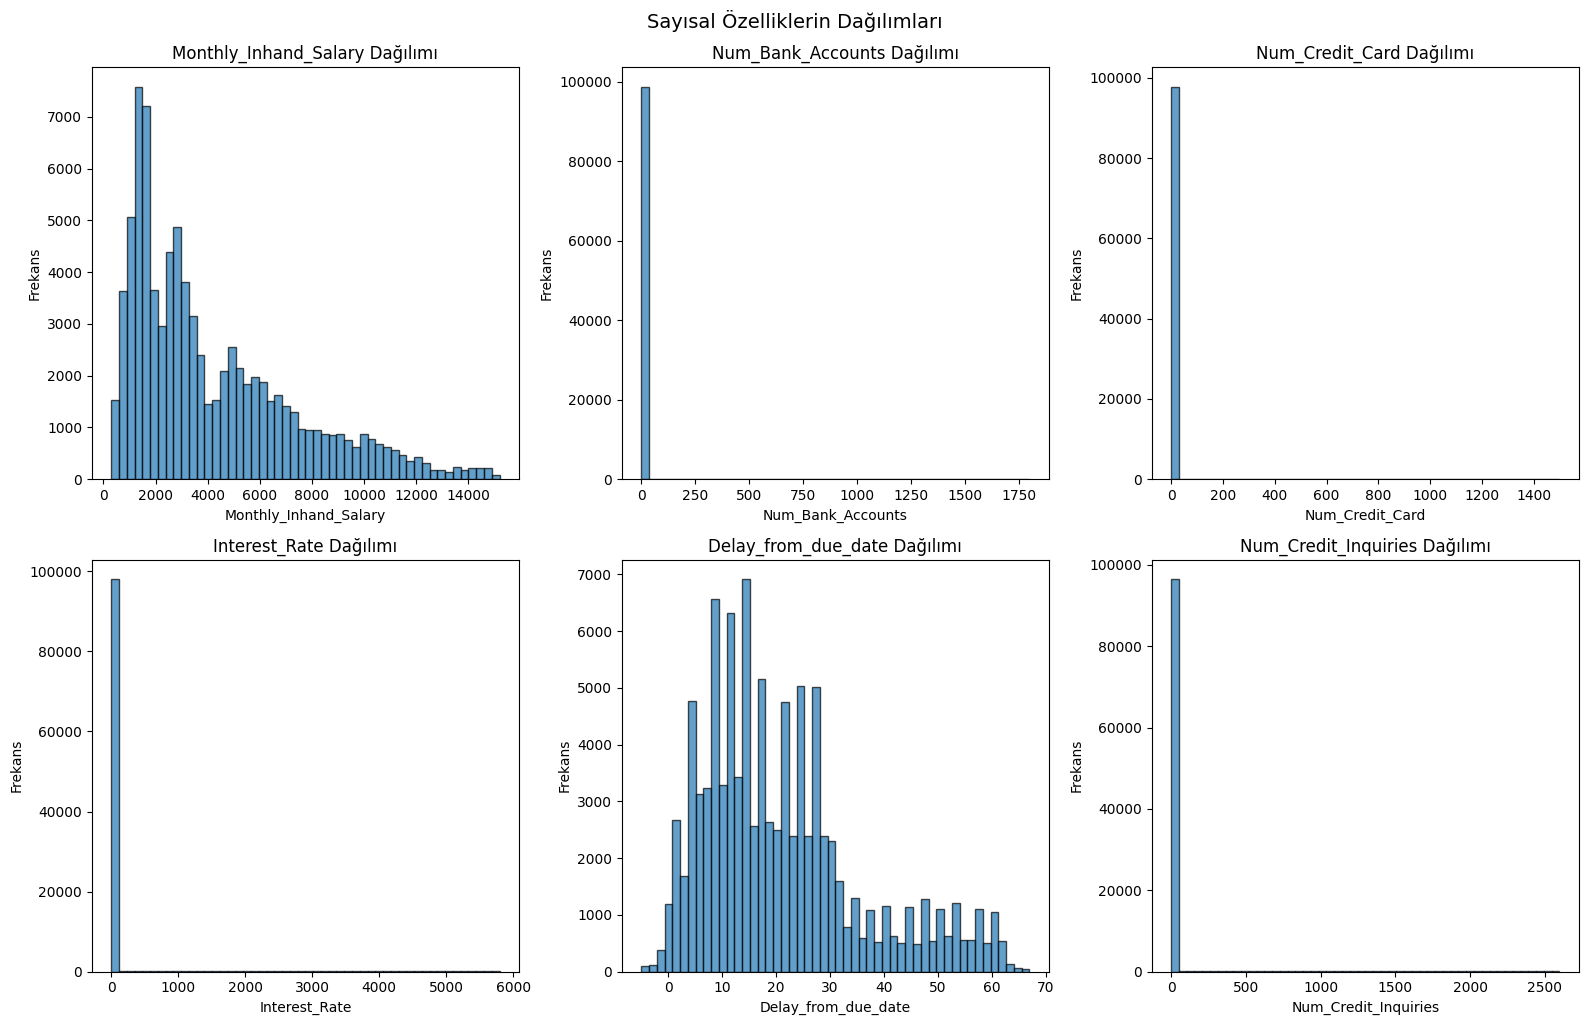

In [5]:
# Sayısal sütunların dağılımı
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Sayısal sütunlar ({len(numeric_cols)}): {numeric_cols}')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:6]):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} Dağılımı')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekans')

for j in range(len(numeric_cols[:6]), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Sayısal Özelliklerin Dağılımları', y=1.02, fontsize=14)
plt.show()

Kategorik sütunlar (20): ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


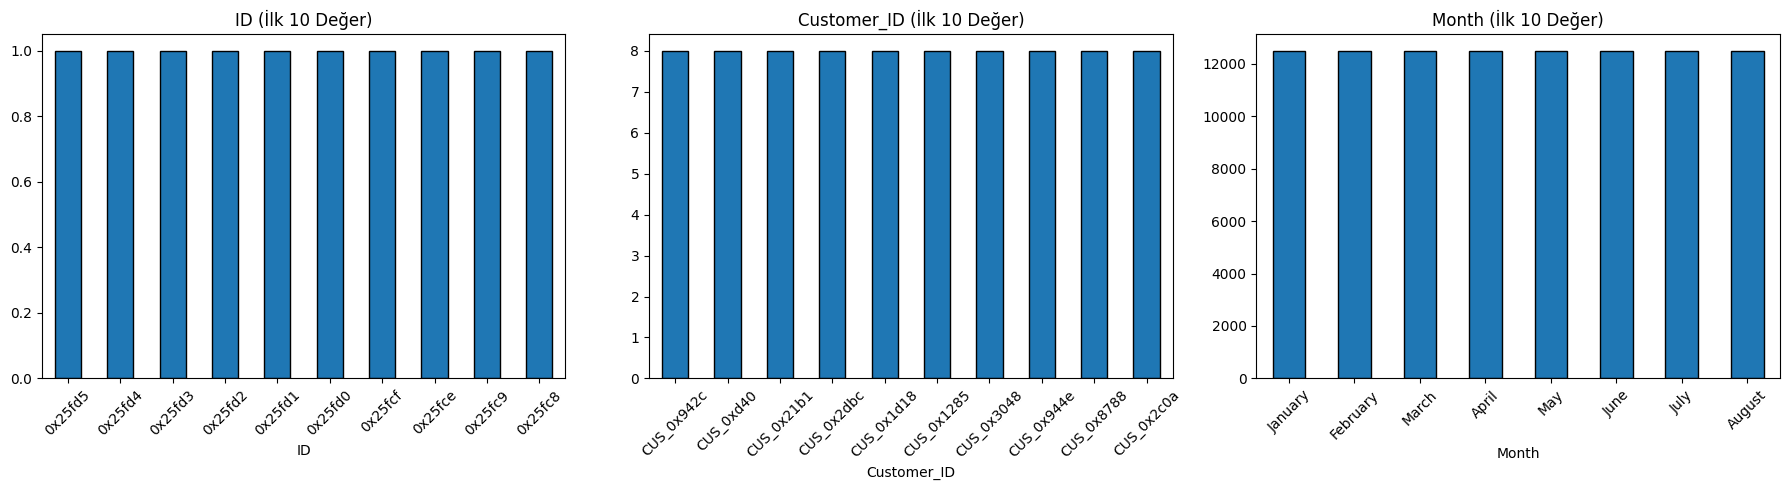

In [6]:
# Kategorik sütunların analizi
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Kategorik sütunlar ({len(cat_cols)}): {cat_cols}')

fig, axes = plt.subplots(1, min(3, len(cat_cols)), figsize=(18, 5))
if min(3, len(cat_cols)) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols[:3]):
    val_counts = df[col].value_counts().head(10)
    val_counts.plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{col} (İlk 10 Değer)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Drift Oluşturma (Referans vs Test)

Referans veri seti (orijinal dağılım) ve test veri seti (drift uygulanmış) oluşturacağız.

In [7]:
# Sayısal sütunları temizle ve準備
df_clean = df.copy()

# Sayısal sütunları seç
numeric_features_raw = ['annual_income', 'monthly_inhand_salary', 'num_bank_accounts',
                    'num_credit_card', 'interest_rate', 'num_of_loan',
                    'delay_from_due_date', 'num_of_delayed_payment',
                    'credit_history_age', 'total_emi_per_month',
                    'amount_invested_monthly', 'monthly_balance']

# Büyük/küçük harf duyarsız eşleştirme (Kaggle uyumlu)
col_map = {c.lower().replace(' ', '_'): c for c in df_clean.columns}
numeric_features = []
for feat in numeric_features_raw:
    if feat in df_clean.columns:
        numeric_features.append(feat)
    elif feat.lower() in col_map:
        real_col = col_map[feat.lower()]
        df_clean = df_clean.rename(columns={real_col: feat})
        numeric_features.append(feat)
print(f'Kullanılacak sayısal özellikler ({len(numeric_features)}): {numeric_features}')

# String değerleri temizle (varsa)
for col in numeric_features:
    if df_clean[col].dtype == 'object':
        df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace('_', '').str.replace('-', ''), errors='coerce')

# Eksik değerleri medyan ile doldur
for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Referans ve test seti oluştur
reference_df = df_clean[numeric_features].iloc[:len(df_clean)//2].reset_index(drop=True)
test_df_original = df_clean[numeric_features].iloc[len(df_clean)//2:].reset_index(drop=True)

# Test setine kasıtlı drift ekle
test_df = test_df_original.copy()
np.random.seed(42)

# Bazı özelliklerin ortalamasını ve sapmasını değiştirerek drift oluştur
drift_features = numeric_features[:4]  # İlk 4 özelliği boz
for col in drift_features:
    shift = test_df[col].mean() * np.random.uniform(0.15, 0.35)  # %15-35 kayma
    test_df[col] = test_df[col] + shift
    # Varyansı da artır
    test_df[col] = test_df[col] * np.random.uniform(1.2, 1.8, size=len(test_df))

print(f'Referans seti boyutu: {reference_df.shape}')
print(f'Test seti boyutu: {test_df.shape}')
print(f'Drift uygulanan özellikler: {drift_features}')

Kullanılacak sayısal özellikler (12): ['annual_income', 'monthly_inhand_salary', 'num_bank_accounts', 'num_credit_card', 'interest_rate', 'num_of_loan', 'delay_from_due_date', 'num_of_delayed_payment', 'credit_history_age', 'total_emi_per_month', 'amount_invested_monthly', 'monthly_balance']
Referans seti boyutu: (50000, 12)
Test seti boyutu: (50000, 12)
Drift uygulanan özellikler: ['annual_income', 'monthly_inhand_salary', 'num_bank_accounts', 'num_credit_card']


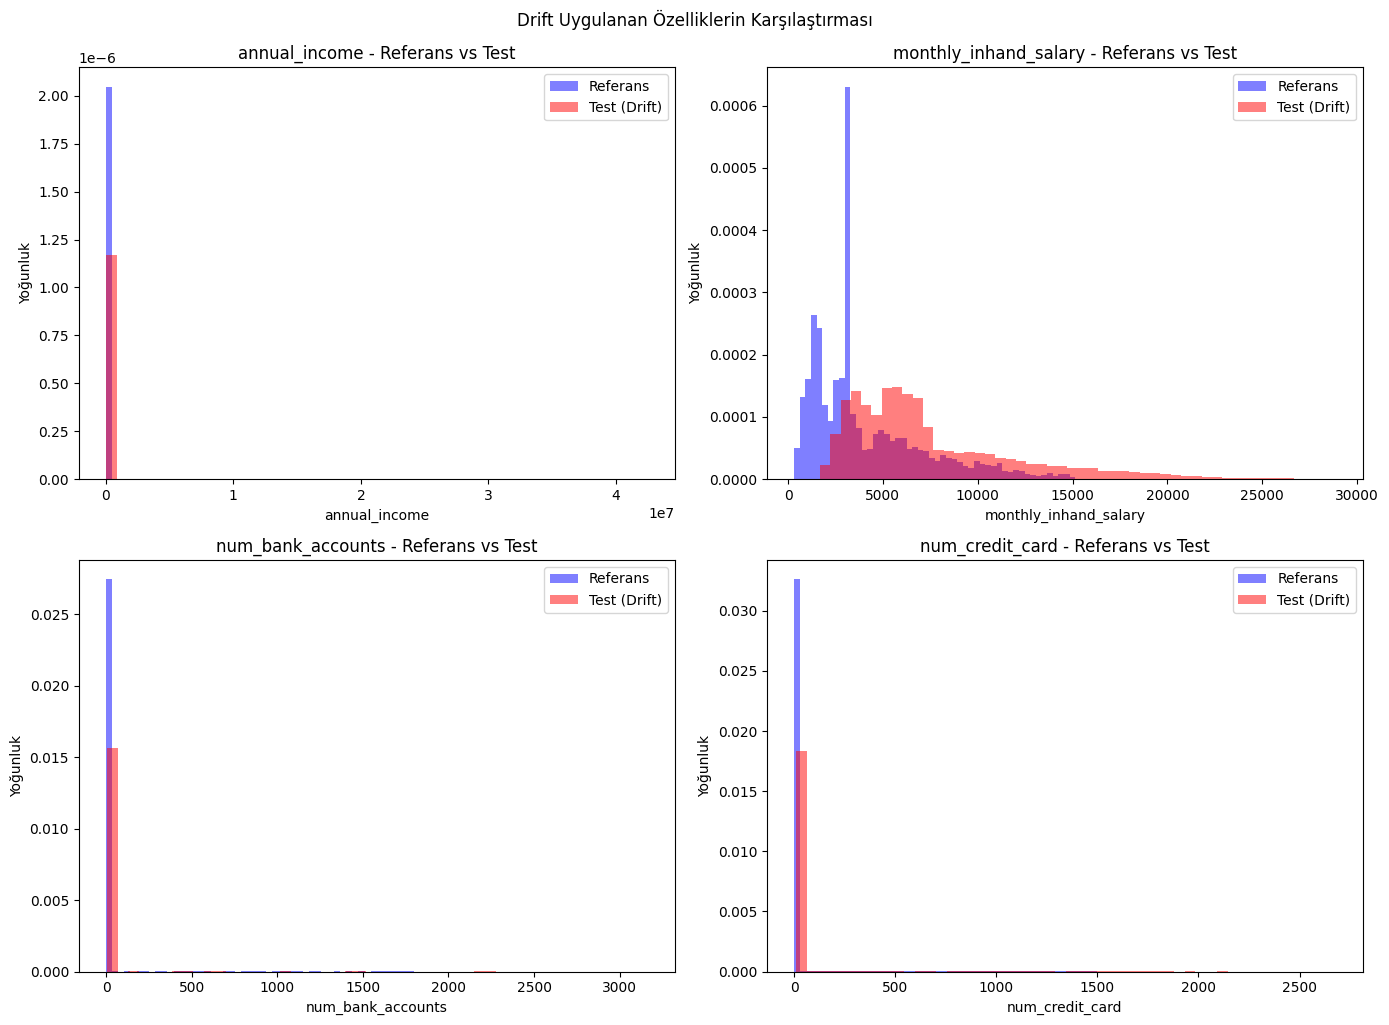

In [8]:
# Drift'i görselleştir
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(drift_features[:4]):
    ax = axes[i // 2][i % 2]
    ax.hist(reference_df[col], bins=50, alpha=0.5, label='Referans', density=True, color='blue')
    ax.hist(test_df[col], bins=50, alpha=0.5, label='Test (Drift)', density=True, color='red')
    ax.set_title(f'{col} - Referans vs Test')
    ax.legend()
    ax.set_xlabel(col)
    ax.set_ylabel('Yoğunluk')

plt.tight_layout()
plt.suptitle('Drift Uygulanan Özelliklerin Karşılaştırması', y=1.02)
plt.show()

## 4. KS Testi (Kolmogorov-Smirnov)

KS testi, iki örneklem dağılımının aynı_POPülasyondan gelip gelmediğini test eder.
- **H₀:** İki dağılım aynıdır
- **p-değeri < 0.05:** Drift mevcuttur

In [9]:
print('=== Kolmogorov-Smirnov Testi Sonuçları ===')
print(f'{"Özellik":<30} {"KS İstatistiği":<15} {"p-değeri":<15} {"Drift?":<10}')
print('-' * 70)

ks_results = []

for col in numeric_features:
    # KS testini uygula
    ks_stat, p_value = stats.ks_2samp(reference_df[col], test_df[col])
    drift_detected = 'EVET' if p_value < 0.05 else 'HAYIR'
    ks_results.append({'feature': col, 'ks_stat': ks_stat, 'p_value': p_value, 'drift': drift_detected})
    print(f'{col:<30} {ks_stat:<15.4f} {p_value:<15.6f} {drift_detected:<10}')

ks_results_df = pd.DataFrame(ks_results)

=== Kolmogorov-Smirnov Testi Sonuçları ===
Özellik                        KS İstatistiği  p-değeri        Drift?    
----------------------------------------------------------------------
annual_income                  0.6855          0.000000        EVET      
monthly_inhand_salary          0.4866          0.000000        EVET      
num_bank_accounts              0.8019          0.000000        EVET      
num_credit_card                0.9735          0.000000        EVET      
interest_rate                  0.0097          0.017305        EVET      
num_of_loan                    0.0167          0.000002        EVET      
delay_from_due_date            0.0107          0.006211        EVET      
num_of_delayed_payment         0.0085          0.054581        HAYIR     
credit_history_age             nan             nan             HAYIR     
total_emi_per_month            0.0118          0.001879        EVET      
amount_invested_monthly        0.0062          0.297728        HAYIR    

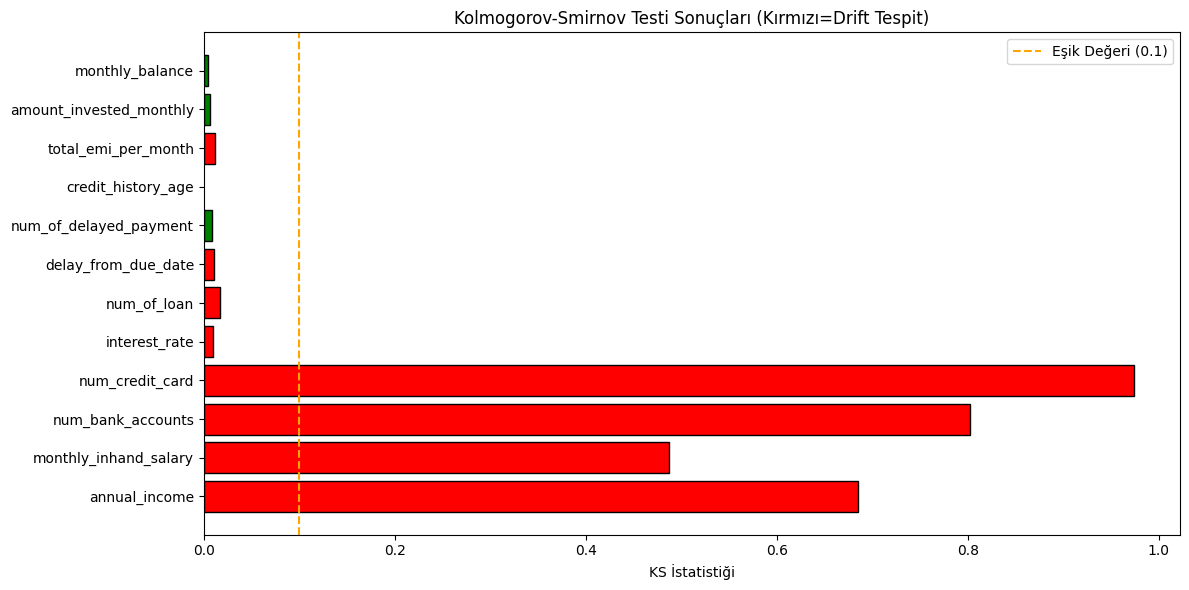

In [10]:
# KS sonuçlarını görselleştir
if len(ks_results_df) == 0:
    print('Uyarı: Sayısal özellik bulunamadı, KS grafik gösterilemiyor.')
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['red' if d == 'EVET' else 'green' for d in ks_results_df['drift']]
    bars = ax.barh(ks_results_df['feature'], ks_results_df['ks_stat'], color=colors, edgecolor='black')
    ax.axvline(x=0.1, color='orange', linestyle='--', label='Eşik Değeri (0.1)')
    ax.set_xlabel('KS İstatistiği')
    ax.set_title('Kolmogorov-Smirnov Testi Sonuçları (Kırmızı=Drift Tespit)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Chi-Kare Testi

Chi-kare testi kategorik özellikler için drift tespitinde kullanılır.
- **H₀:** İki kategorik dağılım aynıdır

In [11]:
# Kategorik sütunlar için Chi-Kare testi
cat_features_for_test = ['credit_mix', 'payment_of_min_amount', 'payment_behaviour']
cat_features_for_test = [f for f in cat_features_for_test if f in df.columns]

print('=== Chi-Kare Testi Sonuçları (Kategorik) ===')
print(f'{"Özellik":<30} {"Chi2 İst.":<15} {"p-değeri":<15} {"Drift?":<10}')
print('-' * 70)

chi2_results = []

if len(cat_features_for_test) > 0:
    # Referans ve test için kategorik verileri hazırla
    ref_cat = df.iloc[:len(df)//2]
    test_cat = df.iloc[len(df)//2:]

    for col in cat_features_for_test:
        # Tüm değerleri string'e çevir
        ref_vals = ref_cat[col].astype(str)
        test_vals = test_cat[col].astype(str)

        # Tüm olası değerleri birleştir
        all_categories = list(set(ref_vals.unique()) | set(test_vals.unique()))

        # Frekans tabloları oluştur
        ref_freq = [sum(ref_vals == cat) for cat in all_categories]
        test_freq = [sum(test_vals == cat) for cat in all_categories]

        # Chi-kare testi
        chi2, p_value, _, _ = stats.chi2_contingency([ref_freq, test_freq])
        drift_detected = 'EVET' if p_value < 0.05 else 'HAYIR'
        chi2_results.append({'feature': col, 'chi2': chi2, 'p_value': p_value, 'drift': drift_detected})
        print(f'{col:<30} {chi2:<15.2f} {p_value:<15.6f} {drift_detected:<10}')
else:
    print('Kategorik sütun bulunamadı.')

=== Chi-Kare Testi Sonuçları (Kategorik) ===
Özellik                        Chi2 İst.       p-değeri        Drift?    
----------------------------------------------------------------------
Kategorik sütun bulunamadı.


## 6. PSI (Population Stability Index)

PSI, iki dağılım arasındaki farkı ölçer:
- **PSI < 0.1:** Drift yok
- **0.1 ≤ PSI < 0.25:** Orta düzey drift
- **PSI ≥ 0.25:** Yüksek drift

In [12]:
def calculate_psi(reference, test, bins=10, eps=1e-4):
    """PSI hesaplama fonksiyonu"""
    # Bin sınırlarını referans verisinden oluştur
    breakpoints = np.percentile(reference, np.linspace(0, 100, bins + 1))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    # Her bin için oranları hesapla
    ref_counts = np.histogram(reference, bins=breakpoints)[0] / len(reference)
    test_counts = np.histogram(test, bins=breakpoints)[0] / len(test)

    # PSI formülü
    ref_counts = np.clip(ref_counts, eps, None)
    test_counts = np.clip(test_counts, eps, None)

    psi = np.sum((test_counts - ref_counts) * np.log(test_counts / ref_counts))
    return psi


print('=== PSI (Population Stability Index) Sonuçları ===')
print(f'{"Özellik":<30} {"PSI":<15} {"Drift Seviyesi":<20}')
print('-' * 65)

psi_results = []

for col in numeric_features:
    psi = calculate_psi(reference_df[col].values, test_df[col].values)
    if psi < 0.1:
        level = 'Drift Yok'
    elif psi < 0.25:
        level = 'Orta Düzey Drift'
    else:
        level = 'Yüksek Drift'

    psi_results.append({'feature': col, 'psi': psi, 'level': level})
    print(f'{col:<30} {psi:<15.4f} {level:<20}')

psi_results_df = pd.DataFrame(psi_results)

=== PSI (Population Stability Index) Sonuçları ===
Özellik                        PSI             Drift Seviyesi      
-----------------------------------------------------------------
annual_income                  5.2321          Yüksek Drift        
monthly_inhand_salary          2.2238          Yüksek Drift        
num_bank_accounts              4.0772          Yüksek Drift        
num_credit_card                8.4400          Yüksek Drift        
interest_rate                  0.0011          Drift Yok           
num_of_loan                    0.0039          Drift Yok           
delay_from_due_date            0.0006          Drift Yok           
num_of_delayed_payment         0.0014          Drift Yok           
credit_history_age             0.0000          Drift Yok           
total_emi_per_month            0.0017          Drift Yok           
amount_invested_monthly        0.0002          Drift Yok           
monthly_balance                0.0003          Drift Yok           

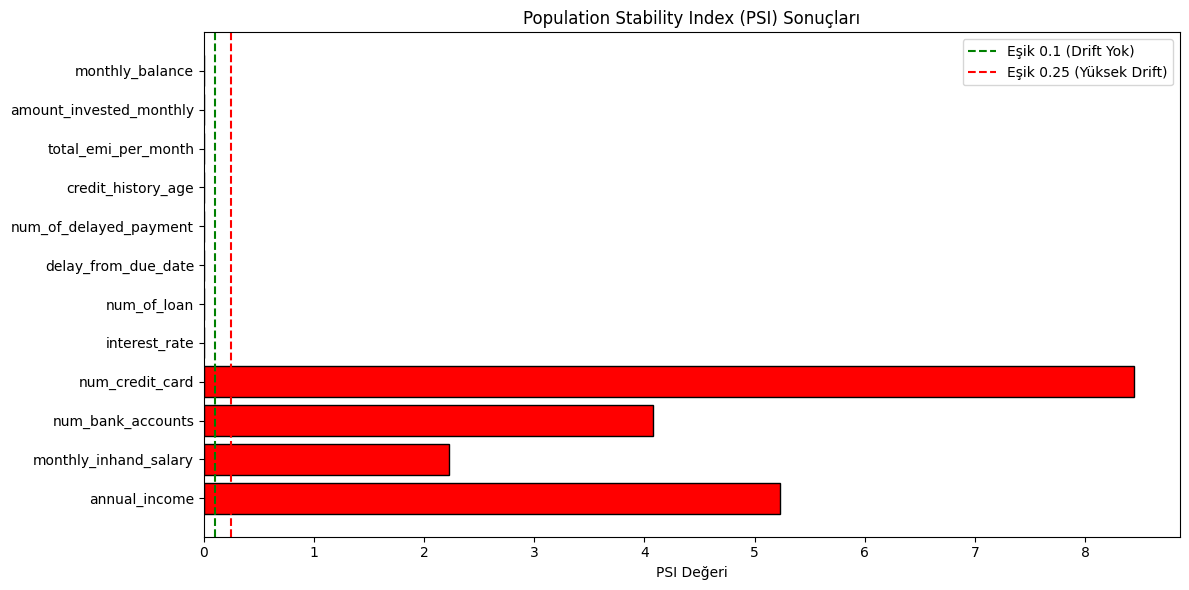

In [13]:
# PSI görselleştirme
fig, ax = plt.subplots(figsize=(12, 6))

colors = []
for psi in psi_results_df['psi']:
    if psi < 0.1:
        colors.append('green')
    elif psi < 0.25:
        colors.append('orange')
    else:
        colors.append('red')

bars = ax.barh(psi_results_df['feature'], psi_results_df['psi'], color=colors, edgecolor='black')
ax.axvline(x=0.1, color='green', linestyle='--', label='Eşik 0.1 (Drift Yok)')
ax.axvline(x=0.25, color='red', linestyle='--', label='Eşik 0.25 (Yüksek Drift)')
ax.set_xlabel('PSI Değeri')
ax.set_title('Population Stability Index (PSI) Sonuçları')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Jensen-Shannon Divergence

JS Divergence, iki olasılık dağılımı arasındaki simetrik farkı ölçer.
- Değer aralığı: [0, 1]
- 0: Dağılımlar aynı, 1: Tamamen farklı

In [14]:
def compute_js_divergence(reference, test, bins=50):
    """Jensen-Shannon Divergence hesaplama"""
    # Histogramları oluştur
    min_val = min(reference.min(), test.min())
    max_val = max(reference.max(), test.max())
    bin_edges = np.linspace(min_val, max_val, bins + 1)

    ref_hist, _ = np.histogram(reference, bins=bin_edges, density=True)
    test_hist, _ = np.histogram(test, bins=bin_edges, density=True)

    # Sıfır değerleri engelle
    ref_hist = ref_hist + 1e-10
    test_hist = test_hist + 1e-10

    # Normalize et
    ref_hist = ref_hist / ref_hist.sum()
    test_hist = test_hist / test_hist.sum()

    # JS Divergence hesapla
    js_div = jensenshannon(ref_hist, test_hist) ** 2  # kare alarak divergens
    return js_div, ref_hist, test_hist


print('=== Jensen-Shannon Divergence Sonuçları ===')
print(f'{"Özellik":<30} {"JS Div.":<15}')
print('-' * 45)

js_results = []

for col in numeric_features:
    js_div, _, _ = compute_js_divergence(reference_df[col].values, test_df[col].values)
    js_results.append({'feature': col, 'js_divergence': js_div})
    print(f'{col:<30} {js_div:<15.6f}')

js_results_df = pd.DataFrame(js_results)

=== Jensen-Shannon Divergence Sonuçları ===
Özellik                        JS Div.        
---------------------------------------------
annual_income                  0.000710       
monthly_inhand_salary          0.185458       
num_bank_accounts              0.001664       
num_credit_card                0.003032       
interest_rate                  0.000337       
num_of_loan                    0.000313       
delay_from_due_date            0.000652       
num_of_delayed_payment         0.000282       
credit_history_age             nan            
total_emi_per_month            0.000333       
amount_invested_monthly        0.000032       
monthly_balance                0.000000       


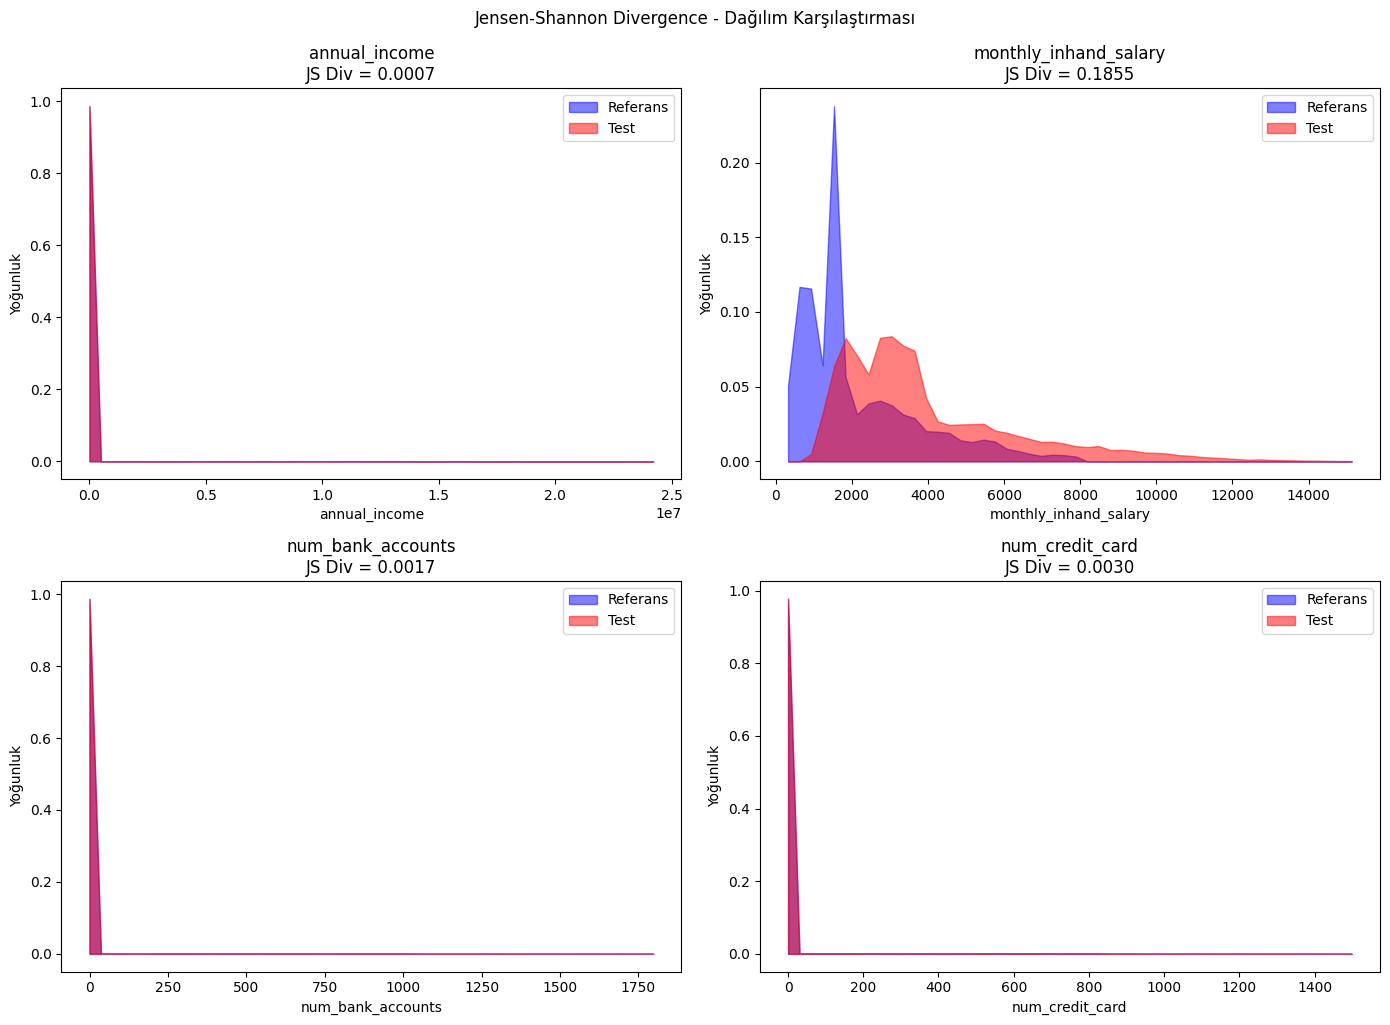

In [15]:
# JS Divergence görselleştirme ve dağılım karşılaştırması
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(drift_features[:4]):
    ax = axes[i // 2][i % 2]
    js_div, ref_hist, test_hist = compute_js_divergence(reference_df[col].values, test_df[col].values)

    x = np.linspace(reference_df[col].min(), reference_df[col].max(), len(ref_hist))
    ax.fill_between(x, ref_hist, alpha=0.5, label='Referans', color='blue')
    ax.fill_between(x, test_hist, alpha=0.5, label='Test', color='red')
    ax.set_title(f'{col}\nJS Div = {js_div:.4f}')
    ax.legend()
    ax.set_xlabel(col)
    ax.set_ylabel('Yoğunluk')

plt.tight_layout()
plt.suptitle('Jensen-Shannon Divergence - Dağılım Karşılaştırması', y=1.02)
plt.show()

## 8. Evidently AI Raporu

Evidently AI, kapsamlı veri drift raporları oluşturur.

In [16]:
# Evidently ile drift raporu
if evidently_available:
    ref_evidently = reference_df.copy()
    test_evidently = test_df.copy()

    # Boş sütunları kaldır
    empty_cols = [c for c in ref_evidently.columns if ref_evidently[c].isna().all() or test_evidently[c].isna().all()]
    if empty_cols:
        print(f'Boş sütunlar atılıyor: {empty_cols}')
        ref_evidently = ref_evidently.drop(columns=empty_cols)
        test_evidently = test_evidently.drop(columns=empty_cols)

    # NaN değerleri medyan ile doldur
    for col in ref_evidently.columns:
        ref_evidently[col] = ref_evidently[col].fillna(ref_evidently[col].median())
        test_evidently[col] = test_evidently[col].fillna(test_evidently[col].median())

    report = Report(metrics=[DataDriftPreset()])
    report.run(reference_data=ref_evidently, current_data=test_evidently)
    # Farklı evidently versiyonları için uyumlu kayıt
    try:
        report.save_html('credit_score_drift_report.html')
    except AttributeError:
        try:
            report.write_html('credit_score_drift_report.html')
        except AttributeError:
            with open('credit_score_drift_report.html', 'w') as f:
                f.write(str(report))
    print('Rapor kaydedildi: credit_score_drift_report.html')
    report
else:
    print('evidently kullanılamıyor. Manuel drift raporu oluşturuluyor...')
    print('\n' + '='*60)
    print('MANUEL DRIFT RAPORU')
    print('='*60)
    for col in reference_df.columns:
        if reference_df[col].dtype in ['float64', 'int64']:
            stat, p = stats.ks_2samp(reference_df[col].dropna(), test_df[col].dropna())
            status = 'DRIFT' if p < 0.05 else 'YOK'
            print(f'{col}: KS={stat:.4f}, p={p:.4f} -> {status}')
        else:
            print(f'{col}: Kategorik sütun (manuel kontrol gerekli)')

Boş sütunlar atılıyor: ['credit_history_age']
Rapor kaydedildi: credit_score_drift_report.html


## 9. Sonuç

### Tüm Testlerin Özeti

| Test | Amaç | Eşik Değeri |
|------|------|------------|
| KS Testi | Sayısal dağılım farkı | p < 0.05 |
| Chi-Kare | Kategorik dağılım farkı | p < 0.05 |
| PSI | Popülasyon kararlılığı | < 0.1 yok, > 0.25 yüksek |
| JS Div | Dağılım benzerliği | 0 = aynı, 1 = farklı |
| Evidently | Kapsamlı otomatik rapor | Otomatik yorumlama |

**Not:** Bu notebook'da kasıtlı olarak oluşturulan drift, gerçek dünya senaryolarında daha yavaş ve kademeli olabilir.